In [1]:
!wget https://naciscdn.org/naturalearth/packages/natural_earth_vector.zip
!mkdir natural_earth_vector
!unzip natural_earth_vector.zip -d ./natural_earth_vector

--2026-03-03 15:46:50--  https://naciscdn.org/naturalearth/packages/natural_earth_vector.zip
Resolving naciscdn.org (naciscdn.org)... 13.33.82.86, 13.33.82.127, 13.33.82.4, ...
Connecting to naciscdn.org (naciscdn.org)|13.33.82.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 587029538 (560M) [application/zip]
Saving to: ‘natural_earth_vector.zip.1’

natural_earth_vecto 100%[===================>] 559.83M   110MB/s    in 5.1s    

2026-03-03 15:46:56 (110 MB/s) - ‘natural_earth_vector.zip.1’ saved [587029538/587029538]

mkdir: cannot create directory ‘natural_earth_vector’: File exists
Archive:  natural_earth_vector.zip
replace ./natural_earth_vector/10m_cultural/ne_10m_admin_0_antarctic_claim_limit_lines.dbf? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [10]:
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patheffects
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm

import re
import pycountry


from pathlib import Path

# World

In [11]:
world = gpd.read_file('./natural_earth_vector/10m_cultural/ne_10m_admin_0_countries.shp')

# Metaphlan dataset metadata

In [12]:
metadata_path = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/dataset/BlancoMiguezA_2023_metadata.tsv")
metadata = pd.read_csv(metadata_path, sep='\t')
metadata = metadata.loc[(metadata['disease_category'] == 'healthy') & (metadata['age_category'] == 'adult')]
display(metadata)

,Sample ID,dataset_name,subject_id,body_site,antibiotics_current_use,study_condition,disease,disease_category,age,age_category,gender,country,lifestyle
16,SAMEA7041133,AsnicarF_2021,predict1_MTG_0001,stool,no,control,healthy,healthy,36.0,adult,female,USA,Westernized
17,SAMEA7041134,AsnicarF_2021,predict1_MTG_0002,stool,no,control,healthy,healthy,24.0,adult,male,GBR,Westernized
18,SAMEA7041135,AsnicarF_2021,predict1_MTG_0003,stool,no,control,healthy,healthy,63.0,adult,female,USA,Westernized
19,SAMEA7041136,AsnicarF_2021,predict1_MTG_0004,stool,no,control,healthy,healthy,53.0,adult,male,GBR,Westernized
20,SAMEA7041137,AsnicarF_2021,predict1_MTG_0005,stool,no,control,healthy,healthy,38.0,adult,male,GBR,Westernized
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19125,wHAXPI034920-8,ZhuF_2020,wHAXPI034920-8,stool,no,control,healthy,healthy,21.0,adult,male,CHN,Westernized
19126,wHAXPI034921-9,ZhuF_2020,wHAXPI034921-9,stool,no,control,healthy,healthy,23.0,adult,male,CHN,Westernized
19127,wHAXPI034922-11,ZhuF_2020,wHAXPI034922-11,stool,no,control,healthy,healthy,21.0,adult,male,CHN,Westernized
19128,wHAXPI034923-12,ZhuF_2020,wHAXPI034923-12,stool,no,control,healthy,healthy,22.0,adult,male,CHN,Westernized


In [13]:
s1 = set(metadata['country'])
s2 = set(world['ADM0_A3'])
print(s1.difference(s2))
print("is subset:", s1.issubset(s2))

set()
is subset: True


In [55]:
def display_geo_counts(
    df: pd.DataFrame, geo_column_name: str, world: pd.DataFrame, ax, cmap_name: str = 'GnBu', 
    show_annotations: bool = True, annotate_area_lb: float = 5.0, show_legend: bool = True,
):
    # Count rows per country
    country_counts = df[geo_column_name].value_counts().rename_axis('name').reset_index(name='count')
    valid_counts = country_counts.dropna(subset=['name'])
    nan_count = df.loc[df[geo_column_name].isna()].shape[0]
    
    # Merge on country name
    merged = world.merge(valid_counts, left_on='ADM0_A3', right_on='name', how='left')

    # Avoid log(0) — set a minimum of 0.1 so zero-count countries stay at the bottom of the scale
    norm = LogNorm(vmin=max(merged['count'].min(), 0.1), vmax=merged['count'].max())
    
    merged.plot(column='count', ax=ax,
                missing_kwds={'color': '#ffffff', 'edgecolor': '#e6e6e6'},
                cmap=cmap_name,
                norm=norm,
                edgecolor='#bbbbbb',
                linewidth=0.3,
                legend=False)
    ax.set_axis_off()

    # Add a text box in the corner showing unlocated records
    if nan_count > 0:
        ax.text(0.1, 0.2, f'⚠ {nan_count} samples of unknown origin',
                transform=ax.transAxes,
                fontsize=9, color='#9e4a5a', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdf0f3',
                          edgecolor='#e8c0c8', alpha=0.9))

    # Manually place a slim horizontal colorbar at the bottom
    if show_legend:
        sm = mpl.cm.ScalarMappable(cmap=cmap_name, norm=norm)
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                            fraction=0.03, pad=0.01, shrink=0.35, aspect=40)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=14, color='#888888', length=3)
        plt.setp(cbar.ax.get_xticklabels(), color='#555555')
        cbar.set_label('Number of records', fontsize=14, color='#555555', labelpad=6)
    
    # Optional: annotate with numbers
    if show_annotations:
        for _, row in merged.dropna(subset=['count']).iterrows():
            row_ct = row['count']
            if row_ct < 100:
                continue
            geom = row.geometry
            if geom.geom_type == 'MultiPolygon':
                geom = max(geom.geoms, key=lambda g: g.area)
            
            # Skip if the largest polygon is too small to display a number
            if geom.area < annotate_area_lb:  # degrees² — tune this threshold as needed
                continue
            
            x, y = geom.centroid.x, geom.centroid.y
            ax.annotate(int(row['count']), xy=(x, y), ha='center', fontsize=18,
                        fontweight='bold',
                        path_effects=[
                            patheffects.withStroke(linewidth=2, foreground='white')
                        ])
    return merged

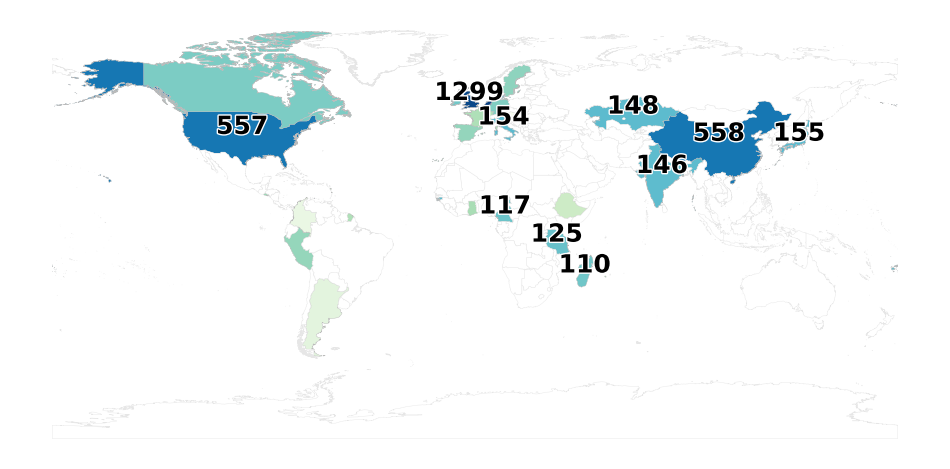

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
annotate_area_lb = 10.0  # don't annotate counts for countries smaller than this area
geo_count_df = display_geo_counts(metadata, 'country', world, ax, show_annotations=True, annotate_area_lb=annotate_area_lb, show_legend=False)
# ax.set_title("2023 Blanco-Miguez et al. (Whole-genome sequencing, Healthy Adults)")

plt.savefig("BlancoMiguez.png", bbox_inches='tight', dpi=800, transparent=True)

# import matplotlib
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.savefig("BlancoMiguez.pdf", bbox_inches='tight')


In [16]:
# fig, axes = plt.subplots(1, 2, figsize=(20, 8))
# annotate_area_lb = 10.0  # don't annotate counts for countries smaller than this area

# ax = axes[1]
# test_samples = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/test.tsv", sep='\t')
# test_metadata = metadata.loc[metadata['Sample ID'].isin(set(test_samples['SampleID']))]
# display_geo_counts(test_metadata, 'country', world, ax, show_annotations=True, annotate_area_lb=annotate_area_lb)
# ax.set_title("MDS-PC1 split: test set")

# ax = axes[0]
# train_samples = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/train.tsv", sep='\t')
# train_metadata = metadata.loc[metadata['Sample ID'].isin(set(train_samples['SampleID']))]
# display_geo_counts(train_metadata, 'country', world, ax, show_annotations=True, annotate_area_lb=annotate_area_lb)
# ax.set_title("MDS-PC1 split: training set")

PC1    0.151897
PC2    0.127875
Name: 0, dtype: float64

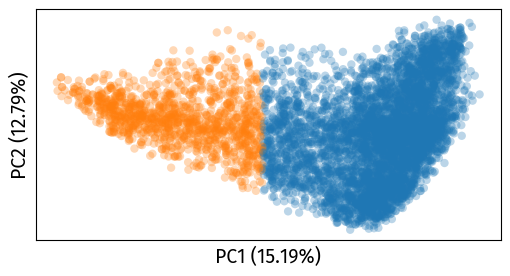

In [17]:
import seaborn as sb

pcoa_df = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_coords.tsv", sep='\t')
prop_var = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_proportion_explained.tsv", sep='\t', index_col=0)['0']
# pcoa_df = pcoa_df.merge(metadata[['Sample ID', 'country']], left_on='SampleId', right_on='Sample ID')
fig, ax = plt.subplots(1, 1, figsize=(6, 3))


#### color by test/train
color_by = 'Label'
colors = {'Train': 'tab:blue', 'Test': 'tab:orange', 'Excluded': 'tab:green'}

# display(pcoa_df)
sb.scatterplot(
    pcoa_df,
    x='PC1', y='PC2', hue=color_by, palette=colors,
    alpha=0.3, linewidth=0., ax=ax
)

display(prop_var)
explained_pc1 = prop_var.loc['PC1']
explained_pc2 = prop_var.loc['PC2']
ax.set_xlabel(f'PC1 ({explained_pc1 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
ax.set_ylabel(f'PC2 ({explained_pc2 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
# ax.set_title('PCoA of samples')
# ax.grid(True, alpha=0.3)
ax.tick_params(
    axis='both',  # Applies to both x and y axis
    which='both', # Applies to both major and minor ticks
    length=0,     # Set tick length to 0 (hides the ticks)
    labelbottom=False, # Hides bottom tick labels
    labelleft=False,   # Hides left tick labels
    labeltop=False,    # Hides top tick labels
    labelright=False   # Hides right tick labels
)
plt.legend().remove()
plt.savefig("pcoa_split.png", bbox_inches='tight', dpi=500, transparent=True)


PC1    0.151897
PC2    0.127875
Name: 0, dtype: float64

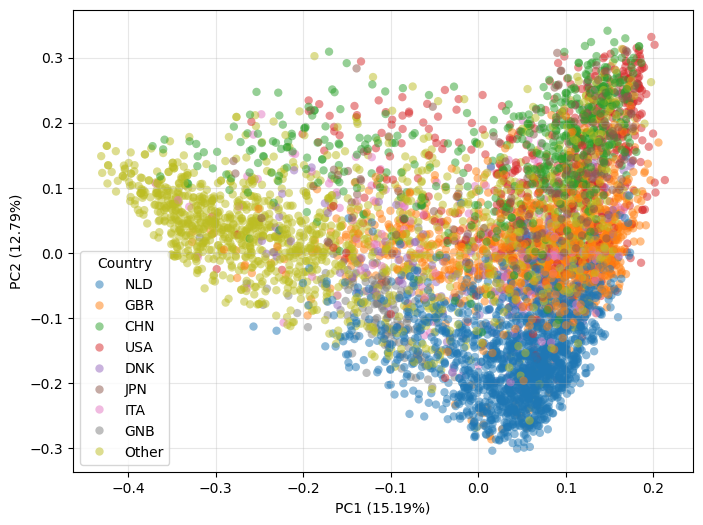

In [116]:
import seaborn as sb
from collections import defaultdict

pcoa_df = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_coords.tsv", sep='\t')
prop_var = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_proportion_explained.tsv", sep='\t', index_col=0)['0']
pcoa_df = pcoa_df.merge(metadata[['Sample ID', 'country']], left_on='SampleId', right_on='Sample ID')
fig, ax = plt.subplots(1, 1, figsize=(8, 6))


#### color by region
hue_order = []
country_display_map = defaultdict(lambda x: 'Other')
_top_counts = geo_count_df.sort_values("count", ascending=False)[['name', 'count']].dropna()
for _, row in _top_counts.iterrows():
    if row['count'] > 150:
        country_display_map[row['name']] = row['name']
        hue_order.append(row['name'])
    else:
        country_display_map[row['name']] = 'Other'
hue_order.append("Other")
pcoa_df['country'] = pcoa_df['country'].map(country_display_map)

# display(pcoa_df)
sb.scatterplot(
    pcoa_df.rename(columns={'country': "Country"}),
    x='PC1', y='PC2', hue='Country', hue_order=hue_order,
    alpha=0.5, linewidth=0., ax=ax
)

display(prop_var)
explained_pc1 = prop_var.loc['PC1']
explained_pc2 = prop_var.loc['PC2']
ax.set_xlabel(f'PC1 ({explained_pc1 * 100:.2f}%)')
ax.set_ylabel(f'PC2 ({explained_pc2 * 100:.2f}%)')
# ax.set_title('PCoA of samples')
ax.grid(True, alpha=0.3)
plt.savefig("pcoa_split_country.png", bbox_inches='tight', dpi=500)


PC1    0.151897
PC2    0.127875
Name: 0, dtype: float64

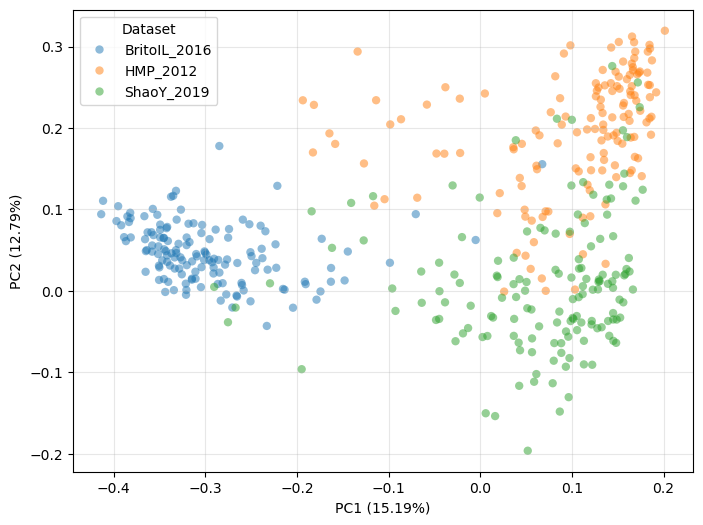

In [42]:
import seaborn as sb
from collections import defaultdict

pcoa_df = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_coords.tsv", sep='\t')
prop_var = pd.read_csv("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/pcoa_proportion_explained.tsv", sep='\t', index_col=0)['0']
pcoa_df = pcoa_df.merge(metadata[['Sample ID', 'dataset_name']], left_on='SampleId', right_on='Sample ID')
fig, ax = plt.subplots(1, 1, figsize=(8, 6))


#### color by dataset
sample_counts = pcoa_df.groupby("dataset_name")['SampleId'].count().sort_values(ascending=False)
# only show the top 5.
dataset_subset = set(sample_counts.head(10).tail(3).index)
pcoa_df = pcoa_df.loc[pcoa_df['dataset_name'].isin(dataset_subset)]

sb.scatterplot(
    pcoa_df.rename(columns={'dataset_name': "Dataset"}),
    x='PC1', y='PC2', hue='Dataset',
    alpha=0.5, linewidth=0., ax=ax
)

display(prop_var)
explained_pc1 = prop_var.loc['PC1']
explained_pc2 = prop_var.loc['PC2']
ax.set_xlabel(f'PC1 ({explained_pc1 * 100:.2f}%)')
ax.set_ylabel(f'PC2 ({explained_pc2 * 100:.2f}%)')
# ax.set_title('PCoA of samples')
ax.grid(True, alpha=0.3)
plt.savefig("pcoa_split_country.png", bbox_inches='tight', dpi=500)


In [49]:
pd.unique(metadata.loc[metadata['dataset_name'] == 'BritoIL_2016', 'country'])

<ArrowStringArray>
['FJI']
Length: 1, dtype: str

In [50]:
pd.unique(metadata.loc[metadata['dataset_name'] == 'ShaoY_2019', 'country'])

<ArrowStringArray>
['GBR']
Length: 1, dtype: str

In [51]:
pd.unique(metadata.loc[metadata['dataset_name'] == 'HMP_2012', 'country'])

<ArrowStringArray>
['USA']
Length: 1, dtype: str